# Sales Prediction using Machine Learning

## Project Overview

This project develops a machine learning regression model to predict product sales based on advertising expenditure across different media platforms.

The project includes:
- Data preprocessing
- Exploratory data analysis
- Data visualization
- Regression model development
- Model evaluation
- Prediction analysis

The objective is to understand how advertising investments influence sales outcomes.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use('default')
sns.set_theme(style="whitegrid")

# Loading the Dataset

The advertising dataset contains advertising budgets for:
- TV
- Radio
- Newspaper

The target variable is:
- Sales

In [2]:
url = "https://raw.githubusercontent.com/ybifoundation/Dataset/main/Advertising.csv"

df = pd.read_csv(url)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# Dataset Information and Statistical Summary

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(200, 4)

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Statistical Summary:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Correlation Heatmap

The heatmap visualizes relationships between advertising channels and sales.

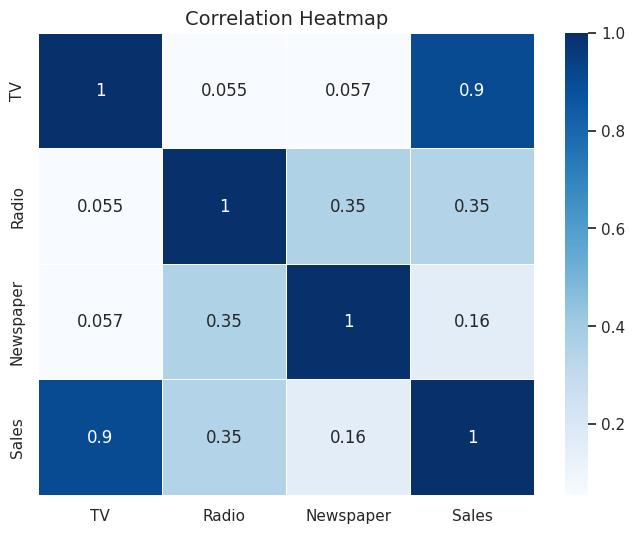

In [4]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=14)

plt.show()

# Relationship Between Advertising and Sales

The following visualizations show how advertising expenditure impacts sales performance.

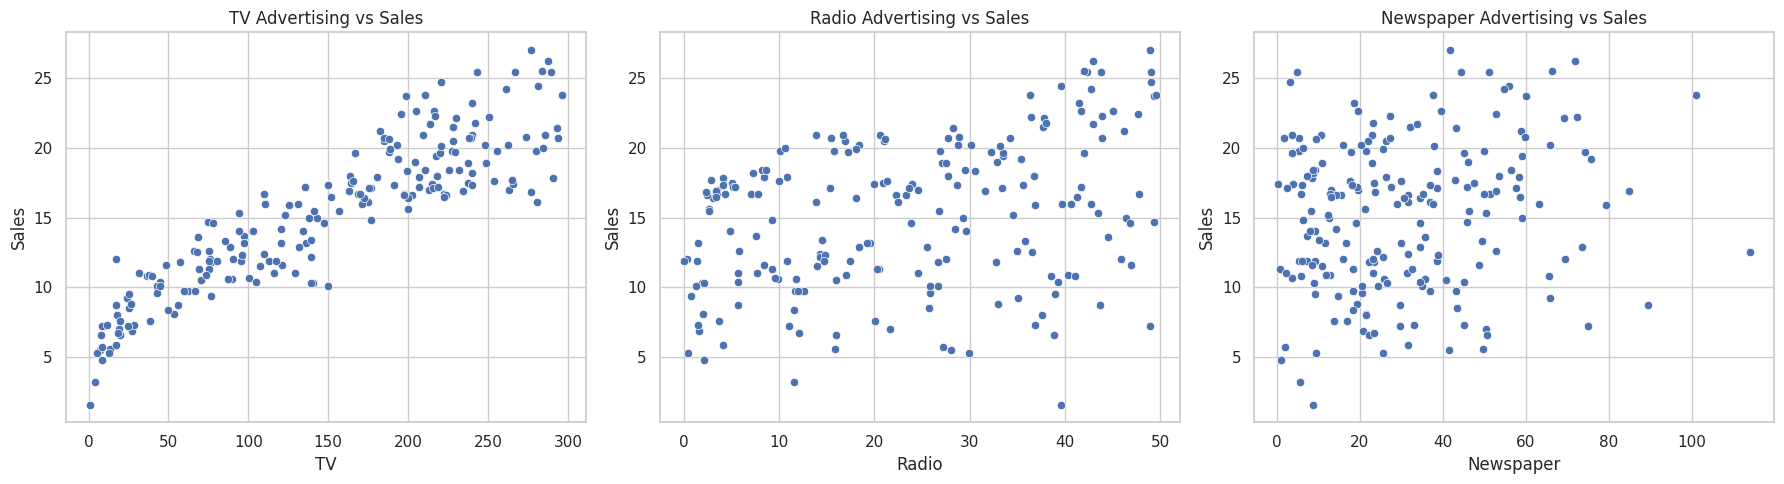

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales',
    ax=axes[0]
)

axes[0].set_title('TV Advertising vs Sales')

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales',
    ax=axes[1]
)

axes[1].set_title('Radio Advertising vs Sales')

sns.scatterplot(
    data=df,
    x='Newspaper',
    y='Sales',
    ax=axes[2]
)

axes[2].set_title('Newspaper Advertising vs Sales')

plt.tight_layout()

plt.show()

# Feature and Target Selection

The advertising expenditure variables are used as input features while sales is used as the target variable.

In [6]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

Feature scaling standardizes the input variables for improved model performance.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

A Linear Regression model is used to predict sales values from advertising expenditure.

In [8]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

# Model Prediction

In [9]:
y_pred = model.predict(X_test_scaled)

# Model Evaluation

The regression model is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:")
print(round(mae, 2))

print("\nMean Squared Error:")
print(round(mse, 2))

print("\nR² Score:")
print(round(r2, 4))

Mean Absolute Error:
1.27

Mean Squared Error:
2.91

R² Score:
0.9059


# Actual vs Predicted Sales

This visualization compares actual sales values with predicted sales values.

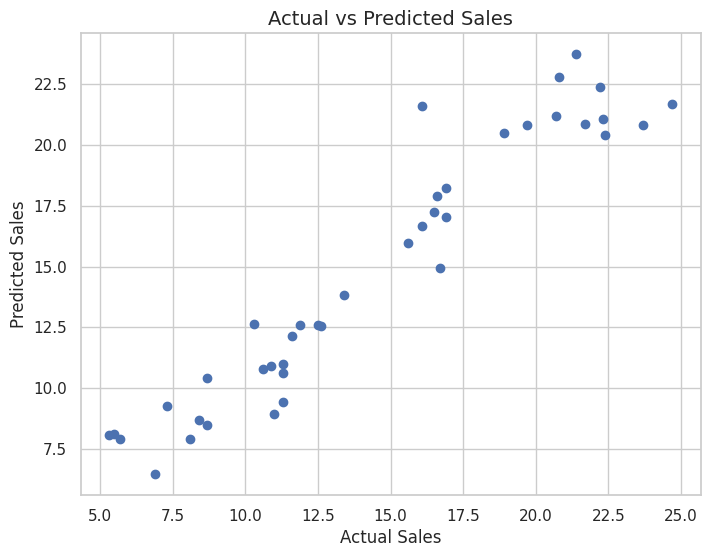

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.title('Actual vs Predicted Sales', fontsize=14)

plt.show()

# Residual Analysis

Residual analysis helps evaluate model prediction errors.

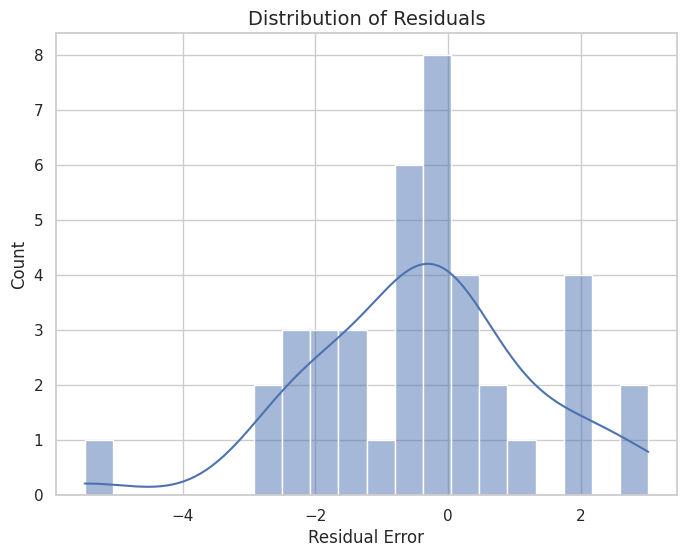

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual Error')

plt.show()

# Feature Importance Analysis

Linear regression coefficients indicate the influence of each advertising channel on sales.

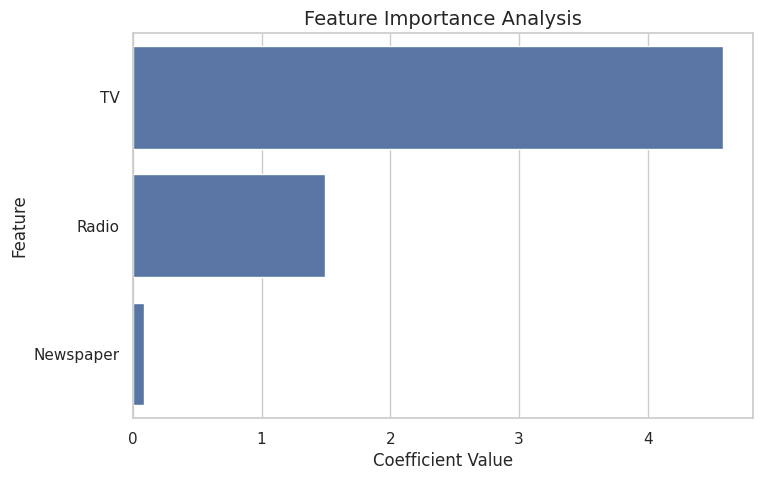

In [13]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature'
)

plt.title('Feature Importance Analysis', fontsize=14)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

plt.show()

# Conclusion

The regression model successfully predicted sales using advertising expenditure data.

Key findings:
- TV advertising showed the strongest relationship with sales.
- Radio advertising also contributed positively to sales performance.
- Newspaper advertising had comparatively lower impact.

The project demonstrates the practical application of regression models in business analytics and marketing prediction tasks.